<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Módulo 1: Implementación de Red Neuronal Artificial con Pytorch</h1>
    <h3>Aprendizaje Automático Avanzado 2026</h3>
</div>


## Introducción a Pytorch

Pytorch es un framework open source para Machine Learning. Al igual que numpy, maneja arrays multidimensionales (aquí llamados *tensores*) y tiene una interfaz parecida(\*). Se destaca en que brinda soporte para redes neuronales (con su módulo de autograd para el cómputo automático de los gradientes) y sus librerías están optimizadas para operar con tensores en GPUs. Junto con [Tensorflow](https://www.tensorflow.org/) son los dos frameworks principales de NNs del momento (otro framework que asoma: [JAX](https://github.com/google/jax)).

Algunas ligas importantes que nos pueden ayudar a tener una idea más detallada de Pytorch son los siguientes:

1. [What is pytorch?](https://pytorch.org/tutorials/beginner/blitz/tensor_tutorial.html#sphx-glr-beginner-blitz-tensor-tutorial-py)
1. [Autograd: automatic differentiation](https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html#sphx-glr-beginner-blitz-autograd-tutorial-py)

Otros links de referencia:

1. [torch package](https://pytorch.org/docs/stable/torch.html)
1. [torch.nn](https://pytorch.org/docs/stable/nn.html)
1. [torch.tensor](https://pytorch.org/docs/stable/tensors.html)
1. [torch.optim](https://pytorch.org/docs/stable/optim.html)



In [1]:
import os

# Evita el conflicto de múltiples runtimes OpenMP (MKL + libgomp) en Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import torch
from torch import nn

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')

# Fijamos las semillas para que los resultados sean reproducibles
np.random.seed(12345)
torch.manual_seed(12345)

print("Versión de PyTorch:", torch.__version__)
print("¿GPU (CUDA) disponible?:", torch.cuda.is_available())

Versión de PyTorch: 2.13.0+cpu
¿GPU (CUDA) disponible?: False


El **tensor** es la estructura de datos central de PyTorch: un arreglo multidimensional muy parecido al `ndarray` de NumPy, pero con dos capacidades adicionales fundamentales para el *deep learning*:

1. Puede ejecutarse en **GPU** para acelerar los cálculos.
2. Registra automáticamente las operaciones para calcular **gradientes** (autograd).


El **autograd** es el motor de PyTorch que calcula gradientes automáticamente. Cuando un tensor se crea con `requires_grad=True`, PyTorch **registra todas las operaciones** que lo involucran en un grafo computacional. Al llamar a `.backward()` sobre el resultado final, recorre ese grafo hacia atrás (regla de la cadena) y almacena las derivadas parciales en el atributo `.grad` de cada tensor.

Este mecanismo es lo que permite **entrenar redes neuronales** sin tener que derivar a mano: PyTorch calcula por nosotros el gradiente de la función de pérdida respecto a cada peso.

**Ejemplo:** para $f(x) = x^2 + 3x + 1$, su derivada es $f'(x) = 2x + 3$. En $x = 2$ esperamos $f'(2) = 7$.


In [2]:
# Creamos un tensor del que queremos calcular gradientes
x = torch.tensor(2.0, requires_grad=True)

# Definimos una función; PyTorch registra cada operación en el grafo computacional
f = x**2 + 3*x + 1

# backward() calcula df/dx y lo guarda en x.grad
f.backward()

print("f(2)  =", f.item())         # valor de la función
print("f'(2) =", x.grad.item())    # derivada automática -> 2*2 + 3 = 7

f(2)  = 11.0
f'(2) = 7.0


## PyTorch y redes neuronales

Antes de entrenar nuestra primera red, repasemos los conceptos clave del proceso de optimización y cómo se reflejan en PyTorch.

### Época, iteración y *batch-size*

- **Época (*epoch*)**: una pasada completa por **todo** el conjunto de entrenamiento (la red ve cada ejemplo una vez).
- **Iteración**: una única actualización de los pesos, realizada tras procesar un *batch*.
- **Batch-size**: el número de ejemplos que se usan para estimar el gradiente antes de cada actualización. Es un hiperparámetro clave.

> Si tenemos $n$ ejemplos y un *batch-size* de $b$, cada época contiene $\lceil n/b \rceil$ iteraciones.

### Variantes del descenso de gradiente

Según el *batch-size* elegido, distinguimos tres algoritmos básicos:

| Variante | Batch-size | Actualizaciones por época | Ventaja | Desventaja |
|---|---|---|---|---|
| **Batch GD** | $n$ (todo) | 1 | Gradiente estable y preciso | Convergencia lenta; costoso en memoria |
| **Stochastic GD (SGD)** | $1$ | $n$ | Actualizaciones frecuentes | Gradiente ruidoso; poco eficiente |
| **Mini-batch GD** | $1 < b < n$ | $n/b$ | **Equilibrio** entre ambos (el más usado) | Hay que ajustar $b$ |

- **Batch gradient descent** ($b = n$): estima el gradiente con la función de costo de **todas** las muestras y actualiza el modelo una sola vez al final de la época.
- **Stochastic gradient descent** ($b = 1$): recorre muestra por muestra (en orden aleatorio), calculando el error y actualizando el modelo tras **cada** una.
- **Mini-batch gradient descent** ($1 < b < n$): divide el entrenamiento en *minibatches*, actualizando el modelo tras cada uno. Es el estándar en la práctica (valores típicos: 32, 64, 128).

> En PyTorch, el *batch-size* se controla con el parámetro `batch_size` del **`DataLoader`**, que se encarga de dividir y barajar los datos automáticamente.

### Learning rate y optimizadores

El **learning rate** ($\eta$) controla el tamaño del paso en cada actualización: $w \leftarrow w - \eta \, \nabla_w L$. Si es muy grande, el entrenamiento puede diverger; si es muy pequeño, será demasiado lento.

En la práctica se usan versiones más refinadas del descenso de gradiente que **adaptan** el paso automáticamente, como **Adam** o **RMSprop**. En PyTorch viven en el módulo [`torch.optim`](https://pytorch.org/docs/stable/optim.html) (`torch.optim.SGD`, `torch.optim.Adam`, ...). Este [post](https://ruder.io/optimizing-gradient-descent/) ofrece una excelente vista general de todas ellas.

### Regularización

Para evitar el **sobreajuste** (*overfitting*), la regularización penaliza que los pesos tomen valores demasiado grandes. La más común es la **regularización L2** (o *weight decay*), que añade a la función de costo el término:

$$
L_2 = \lambda \, \lVert \mathbf{w} \rVert_2^2 = \lambda \sum_{i,j} w_{ij}^2,
$$

donde $\lambda$ (el *weight decay*) es un hiperparámetro pequeño, por ejemplo $\lambda = 1\times10^{-3}$.

> En PyTorch, la regularización L2 se activa directamente con el parámetro `weight_decay` del optimizador, p. ej. `torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-3)`. Otra técnica muy usada es el **dropout** (`nn.Dropout`), que desactiva aleatoriamente una fracción de neuronas durante el entrenamiento.


### Ejemplo Sencillo de una Regresión polinomial

Primero, generamos un dataset "de juguete" con la función provista en el módulo *utils.py*. **Importante:** el módulo *utils.py* del repositorio debe encontrarse en la misma carpeta que el notebook, de lo contrario no se podrán correr funciones como *create_sinusoidal_data*.

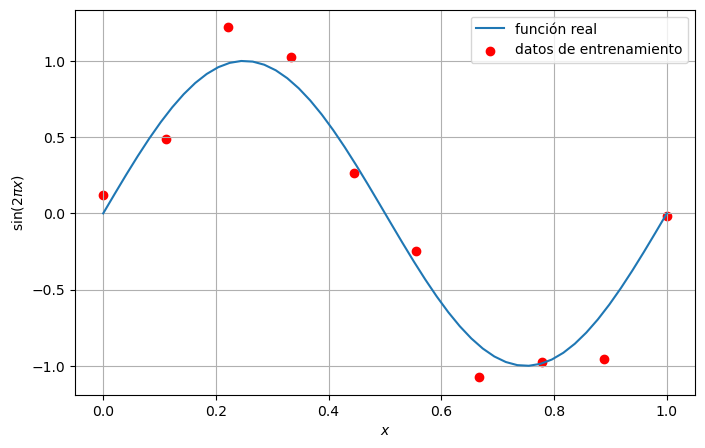

In [4]:
from utils import create_sinusoidal_data as create_data

# x_train/y_train: 10 puntos con ruido (rojo) | x_test/y_test: la curva real sin(2*pi*x)
x_train, y_train, x_test, y_test = create_data()

plt.figure(figsize=(8, 5))
plt.plot(x_test, y_test, label='función real')
plt.scatter(x_train, y_train, color='red', label='datos de entrenamiento')
plt.ylabel(r'$\sin(2 \pi x)$')
plt.xlabel(r'$x$')
plt.legend()
plt.grid()
plt.show()

Usaremos dos redes neuronales. Para la primera trabajaremos con el siguiente modelo polinomial de orden $P$, para cada entrada $i$:
$$
y(x; \mathbf{w}) = \sum_{p=0}^P w_p x^p,
$$
el cual podemos expresar como un modelo linear en $\mathbb{R}^{P+1}$ como:

$$
y(x; \mathbf{w}) = \mathbf{w}^T \mathbf{x} + w_0,
$$

donde $$\mathbf{w}={(w_1, \dots, w_P)}^T$$ $$\mathbf{x}={(x, x^2, \dots, x^P)}^T$$ y $w_0$ es el sesgo (bias)

La función ``polynomial_features`` provee dicha funcionalidad.

In [5]:
from utils import polynomial_features

P = 3

x_train_vec = polynomial_features(x_train, P)
y_train_vec = y_train.reshape(-1, 1) # aumentamos nuestro tensor de 1D a 2D pues así lo usará nuestro modelo

x_test_vec = polynomial_features(x_test, P)
y_test_vec = y_test.reshape(-1, 1)

print(x_train_vec.shape, x_test_vec.shape)

(10, 3) (50, 3)


In [6]:
print(x_train)

[0.         0.77777778 0.33333333 1.         0.66666667 0.44444444
 0.11111111 0.88888889 0.55555556 0.22222222]


In [7]:
print(x_train_vec)

[[0.         0.         0.        ]
 [0.77777778 0.60493827 0.47050754]
 [0.33333333 0.11111111 0.03703704]
 [1.         1.         1.        ]
 [0.66666667 0.44444444 0.2962963 ]
 [0.44444444 0.19753086 0.0877915 ]
 [0.11111111 0.01234568 0.00137174]
 [0.88888889 0.79012346 0.70233196]
 [0.55555556 0.30864198 0.17146776]
 [0.22222222 0.04938272 0.01097394]]


Cada $x_i \in X_{train}$ procesado con polynomial features sirve como entrada de las siguientes redes neuronales. Las mismas procesan cada una de las entradas $i$ con la primera arquitectura (la segunda es la que hay que implementar en el TP2).

![Red neuronal de ejemplo](Figures/red_nn_ejemplo.png)

### Definición del modelo

En PyTorch, un modelo se define como una clase que **hereda de `nn.Module`**. Hay dos métodos clave:

- **`__init__`**: donde se declaran las **capas** (por ejemplo, `nn.Linear`). PyTorch registra automáticamente sus parámetros (pesos y sesgos) para poder optimizarlos.
- **`forward`**: define el **paso hacia adelante** (*forward pass*), es decir, cómo fluyen los datos de entrada a través de las capas hasta producir la salida.

`nn.Linear(in_features, out_features)` implementa una capa **densa** (totalmente conectada) que calcula $y = \mathbf{W}\mathbf{x} + \mathbf{b}$.

Definimos dos modelos:
1. **`LinearRegression`**: una sola capa lineal (equivale a una regresión lineal sobre las *features* polinomiales).
2. **`FeedforwardNet`**: un perceptrón multicapa (MLP) con una capa oculta y activación no lineal, capaz de aprender relaciones más complejas.


In [8]:
class LinearRegression(nn.Module):
    """Modelo lineal: una única capa densa sin activación."""
    def __init__(self, num_features):
        super().__init__()
        # Capa densa: recibe 'num_features' entradas y produce 1 salida (la predicción)
        self.fc = nn.Linear(in_features = num_features, out_features = 1, bias = 1)

    def forward(self, x):
        # El forward pass simplemente aplica la capa lineal
        out = self.fc(x)
        return out


class FeedforwardNet(nn.Module):
    """Perceptrón multicapa (MLP) con una capa oculta y activación no lineal."""
    def __init__(self, num_features, num_hidden):
        super().__init__()
        # Capa oculta: proyecta las 'num_features' entradas a 'num_hidden' neuronas
        self.fc1 = nn.Linear(in_features = num_features, out_features = num_hidden, bias = True)

        # Activación no lineal: permite aprender relaciones que no son lineales
        self.activation = nn.Tanh()

        # Capa de salida: de 'num_hidden' neuronas a 1 valor (regresión)
        self.fc2 = nn.Linear(in_features = num_hidden, out_features = 1, bias = True)

    def forward(self, x):
        # entrada -> capa oculta
        x = self.fc1(x)
        x = self.activation(x) 
        out = self.fc2(x)

        # capa oculta -> salida
        return out

Instanciamos nuestro modelo

In [9]:
# Instanciamos nuestro modelo
model = LinearRegression(num_features = P)  # modelo lineal

# si tenemos GPU
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else:
    device = torch.device('cpu')    

model.to(device)

LinearRegression(
  (fc): Linear(in_features=3, out_features=1, bias=True)
)

Probamos nuestro modelo en modo evaluación

In [10]:
# model.eval() pone el modelo en modo "evaluación", desactivando comportamientos
# propios del entrenamiento (como dropout o batchnorm). Se reactivan con model.train()
model.eval()

# torch.no_grad() desactiva el cálculo de gradientes: ahorra memoria y acelera,
# ya que durante la evaluación no necesitamos retropropagar
with torch.no_grad():
    # Convertimos las features (NumPy) a un tensor float32 y lo movemos al dispositivo
    inputs_all = torch.from_numpy(np.float32(x_test_vec)).to(device)

    # una sola muestra
    input_single = inputs_all[1]

    # predicción para esa muestra
    output_single = model(input_single)

    # predicción para todas las muestras
    outputs_all = model(inputs_all)

    print(f'Ejemplo 1 vector de entrada {input_single}')
    print(f'Salida del vector de entrada: {output_single}')
    print(f'Salida para cada vector de entrada: {outputs_all}')


Ejemplo 1 vector de entrada tensor([2.0408e-02, 4.1649e-04, 8.4999e-06])
Salida del vector de entrada: tensor([-0.0334])
Salida para cada vector de entrada: tensor([[-0.0450],
        [-0.0334],
        [-0.0215],
        [-0.0091],
        [ 0.0037],
        [ 0.0170],
        [ 0.0308],
        [ 0.0451],
        [ 0.0600],
        [ 0.0755],
        [ 0.0916],
        [ 0.1084],
        [ 0.1259],
        [ 0.1441],
        [ 0.1630],
        [ 0.1827],
        [ 0.2032],
        [ 0.2245],
        [ 0.2467],
        [ 0.2698],
        [ 0.2937],
        [ 0.3187],
        [ 0.3446],
        [ 0.3715],
        [ 0.3994],
        [ 0.4284],
        [ 0.4585],
        [ 0.4897],
        [ 0.5221],
        [ 0.5556],
        [ 0.5903],
        [ 0.6263],
        [ 0.6635],
        [ 0.7021],
        [ 0.7419],
        [ 0.7831],
        [ 0.8257],
        [ 0.8697],
        [ 0.9151],
        [ 0.9620],
        [ 1.0104],
        [ 1.0603],
        [ 1.1117],
        [ 1.1648],
       

### Función de costo y algoritmo de optimización

Utilizaremos la función de costo error cuadrático medio (MSE) y optimizamos el modelo con descenso de gradiente estocástico (SGD).

In [11]:
from torch.optim import SGD

# modelo nuevamente activado para entrenamiento
model.train()

LEARNING_RATE = 0.1
WEIGHT_DECAY = 0.0  # L2 regularization coef.

criterion = nn.MSELoss(reduction = 'sum')  # Mean Squared Error
optimizer = SGD(model.parameters(), lr = LEARNING_RATE, weight_decay = WEIGHT_DECAY)


### Entrenamiento

A diferencia de Keras (donde basta con `model.fit()`), en PyTorch **escribimos explícitamente el bucle de entrenamiento**. Esto da más control y transparencia. En cada época se repiten estos **5 pasos fundamentales**:

1. **`optimizer.zero_grad()`** — pone a cero los gradientes acumulados de la iteración anterior (PyTorch los acumula por defecto).
2. **`y_pred = model(x)`** — *forward pass*: el modelo calcula sus predicciones.
3. **`loss = criterion(y_pred, y)`** — se calcula la pérdida (qué tan lejos están las predicciones del valor real).
4. **`loss.backward()`** — *backward pass*: autograd calcula el gradiente de la pérdida respecto a cada peso.
5. **`optimizer.step()`** — el optimizador actualiza los pesos en la dirección que reduce la pérdida.

Guardamos la pérdida de entrenamiento y de prueba en cada época para poder graficarlas después.


In [13]:
EPOCHS = 10000

#x_train_tensor, y_train_tensor
x_train_tensor = torch.from_numpy(np.float32(x_train_vec)).to(device)
y_train_tensor = torch.from_numpy(np.float32(y_train_vec)).to(device)
n_train = len(x_train_tensor)

#x_test_tensor, y_test_tensor
x_test_tensor = torch.from_numpy(np.float32(x_test_vec)).to(device)
y_test_tensor = torch.from_numpy(np.float32(y_test_vec)).to(device)
n_test = len(x_test_tensor)


#loss
train_loss = []
test_loss = []

for epoch in range(EPOCHS):
        
    # limpia todos los gradientes
    optimizer.zero_grad()

    # realiza predicción con el modelo (forward pass)
    y_pred = model(x_train_tensor)

    # calcula la pérdida (loss) y la divide por # obs
    loss = criterion(y_pred, y_train_tensor) / n_train

    # calcula los gradientes (backward pass)
    loss.backward()

    # realiza paso de optimización, actualizando pesos
    optimizer.step()
    train_loss.append(loss.detach().item())
    
    with torch.no_grad():
        # predicción en base del modelo
        y_pred = model(x_test_tensor)
        loss = criterion(y_pred, y_test_tensor) / n_test
        test_loss.append(loss.item())

    if epoch % (EPOCHS//10) == 0:
        print(f'Epoch {epoch}: train loss = {train_loss[-1]:.4f}, test loss = {test_loss[-1]:.4f}')

Epoch 0: train loss = 1.6399, test loss = 1.0753
Epoch 1000: train loss = 0.3066, test loss = 0.1916
Epoch 2000: train loss = 0.2886, test loss = 0.1782
Epoch 3000: train loss = 0.2726, test loss = 0.1670
Epoch 4000: train loss = 0.2576, test loss = 0.1566
Epoch 5000: train loss = 0.2436, test loss = 0.1469
Epoch 6000: train loss = 0.2304, test loss = 0.1378
Epoch 7000: train loss = 0.2180, test loss = 0.1293
Epoch 8000: train loss = 0.2063, test loss = 0.1214
Epoch 9000: train loss = 0.1954, test loss = 0.1139


### Visualización

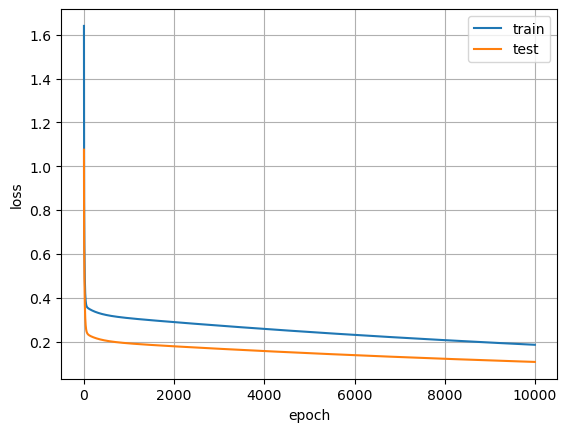

In [14]:
# Curva de pérdida: entrenamiento vs. prueba a lo largo de las épocas
plt.figure()
plt.plot(np.arange(EPOCHS), train_loss)
plt.plot(np.arange(EPOCHS), test_loss)
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'])
plt.grid()
plt.show()


In [15]:
# Predicción del modelo (naranja) frente a la función real (azul)
model.eval()  # modo evaluación
y_pred = model(x_test_tensor)
y_pred = y_pred.cpu().detach().squeeze()  # movemos a CPU y convertimos a NumPy


In [16]:
x_test

array([0.        , 0.02040816, 0.04081633, 0.06122449, 0.08163265,
       0.10204082, 0.12244898, 0.14285714, 0.16326531, 0.18367347,
       0.20408163, 0.2244898 , 0.24489796, 0.26530612, 0.28571429,
       0.30612245, 0.32653061, 0.34693878, 0.36734694, 0.3877551 ,
       0.40816327, 0.42857143, 0.44897959, 0.46938776, 0.48979592,
       0.51020408, 0.53061224, 0.55102041, 0.57142857, 0.59183673,
       0.6122449 , 0.63265306, 0.65306122, 0.67346939, 0.69387755,
       0.71428571, 0.73469388, 0.75510204, 0.7755102 , 0.79591837,
       0.81632653, 0.83673469, 0.85714286, 0.87755102, 0.89795918,
       0.91836735, 0.93877551, 0.95918367, 0.97959184, 1.        ])

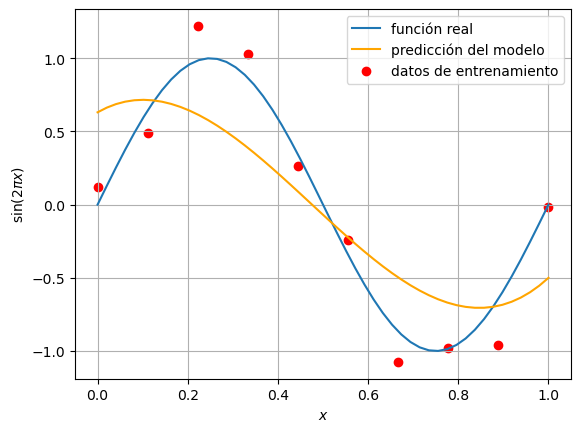

In [ ]:
plt.figure()
plt.plot(x_test, y_test, label='función real')
plt.plot(x_test, y_pred, color='orange', label='predicción del modelo')
plt.scatter(x_train, y_train, color='red', label='datos de entrenamiento')
plt.ylabel(r'$\sin(2 \pi x)$')
plt.xlabel(r'$x$')
plt.legend()
plt.grid()
plt.show()

### Usando data loaders y mini-batch SGD

Volvemos a instanciar el modelo, criterio y optimizador:

In [18]:
model = LinearRegression(num_features=P)

if torch.cuda.is_available():
    device = torch.device('cuda:0')
else:
    device = torch.device('cpu')    

model.to(device)

criterion = nn.MSELoss(reduction='sum')

optimizer = SGD(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

Pytorch provee distintas clases para el accesso a datos, como los *TensorDataset* y *DataLoader*.

* **DataLoader** nos permite realizar iteraciones sobre un dataset. Es especialmente útil para iterar sobre datasets grandes, como por ejemplo los datasets de imágenes, permitiendo abstraernos de tener que implementar código específico para manejar aspectos como las rutas de los archivos o la aleatoriedad en su iteración.

* **TensorDataset**, por otra parte, nos permite generar un dataset de tensores para ser iterado a partir del DataLoader.


In [19]:
from torch.utils import data

BATCH_SIZE = 5

#Train data y data loader
train_data = data.TensorDataset(x_train_tensor, y_train_tensor)
train_loader = data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

#test data y data loader
test_data = data.TensorDataset(x_test_tensor, y_test_tensor)
test_loader = data.DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


In [20]:
train_loss, test_loss = [], []

for epoch in range(EPOCHS):
       
    train_loss_acc = 0.    
    for x, y in train_loader:
        x.to(device, non_blocking=True)
        y.to(device, non_blocking=True)
                
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y) / BATCH_SIZE
        loss.backward()
        optimizer.step()
        
        train_loss_acc += loss.detach().item()
    train_loss.append(train_loss_acc / len(train_data))        
    
    with torch.no_grad():
        test_loss_acc = 0.
        for x, y in test_loader:        
            x.to(device, non_blocking=True)
            y.to(device, non_blocking=True)        
            
            y_pred = model(x)      
            loss = criterion(y_pred, y)
            
            test_loss_acc += loss.item()    
        test_loss.append(test_loss_acc / len(test_data))
        
    if epoch % (EPOCHS//10) == 0:
        print("epoch = {:02d}, train_loss = {:.3e}, test_loss = {:.3e}".format(epoch, train_loss_acc, test_loss_acc))

epoch = 00, train_loss = 9.551e-01, test_loss = 1.595e+01
epoch = 1000, train_loss = 5.867e-01, test_loss = 8.918e+00
epoch = 2000, train_loss = 5.215e-01, test_loss = 7.801e+00
epoch = 3000, train_loss = 5.127e-01, test_loss = 6.847e+00
epoch = 4000, train_loss = 4.130e-01, test_loss = 6.015e+00
epoch = 5000, train_loss = 3.792e-01, test_loss = 5.304e+00
epoch = 6000, train_loss = 3.327e-01, test_loss = 4.687e+00
epoch = 7000, train_loss = 3.027e-01, test_loss = 4.128e+00
epoch = 8000, train_loss = 2.831e-01, test_loss = 3.619e+00
epoch = 9000, train_loss = 2.472e-01, test_loss = 3.209e+00


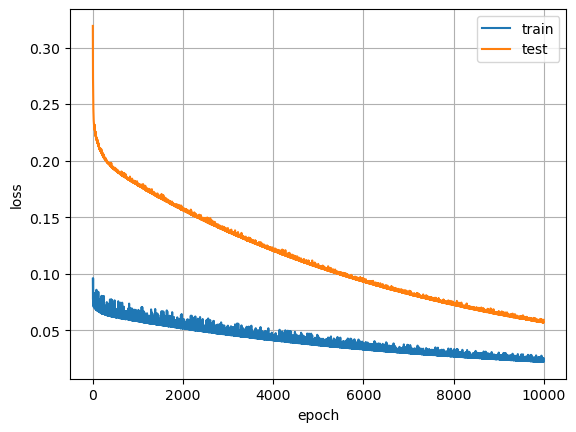

In [21]:
# Curva de pérdida del entrenamiento con mini-batch
plt.figure()
plt.plot(np.arange(EPOCHS), train_loss)
plt.plot(np.arange(EPOCHS), test_loss)
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'])
plt.grid()
plt.show()


In [22]:
# predicción 
model.eval()
y_pred = model(x_test_tensor)
y_pred = y_pred.cpu().detach().numpy().squeeze()


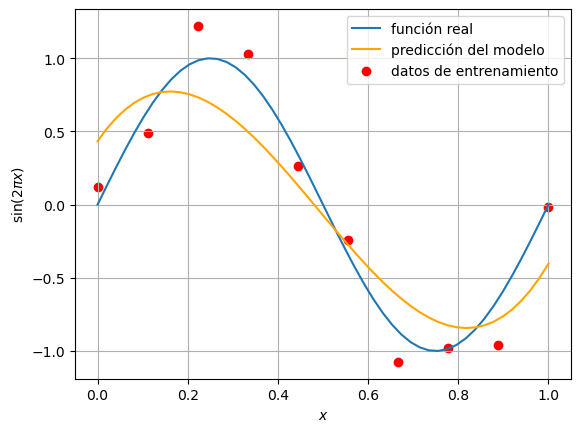

In [23]:
plt.figure()
plt.plot(x_test, y_test, label='función real')
plt.plot(x_test, y_pred, color='orange', label='predicción del modelo')
plt.scatter(x_train, y_train, color='red', label='datos de entrenamiento')
plt.ylabel(r'$\sin(2 \pi x)$')
plt.xlabel(r'$x$')
plt.legend()
plt.grid()
plt.show()

## Ejemplo con una red neuronal (MLP)

Hasta ahora usamos un modelo **lineal** sobre las *features* polinomiales. Ahora entrenamos la **`FeedforwardNet`** (un perceptrón multicapa con una capa oculta y activación no lineal `Tanh`) para ver cómo una red neuronal aprende la función seno. Reutilizamos exactamente el mismo bucle de entrenamiento; lo único que cambia es el **modelo**.

Usaremos el optimizador **Adam**, que suele converger más rápido que el SGD básico.

In [24]:
from torch.optim import Adam

# Instanciamos el MLP: P features de entrada, 32 neuronas en la capa oculta
mlp = FeedforwardNet(num_features=P, num_hidden=32).to(device)

criterion = nn.MSELoss(reduction='mean')
optimizer = Adam(mlp.parameters(), lr=0.01, weight_decay=WEIGHT_DECAY)

EPOCHS_MLP = 2000
train_loss_mlp, test_loss_mlp = [], []

mlp.train()
for epoch in range(EPOCHS_MLP):
    # Los 5 pasos del bucle de entrenamiento
    optimizer.zero_grad()                       # 1. limpiar gradientes
    y_pred = mlp(x_train_tensor)                # 2. forward pass
    loss = criterion(y_pred, y_train_tensor)    # 3. calcular la pérdida
    loss.backward()                             # 4. backward pass (gradientes)
    optimizer.step()                            # 5. actualizar pesos
    train_loss_mlp.append(loss.item())

    with torch.no_grad():
        test_loss_mlp.append(criterion(mlp(x_test_tensor), y_test_tensor).item())

    if epoch % (EPOCHS_MLP // 10) == 0:
        print(f"epoch = {epoch:04d}, train_loss = {train_loss_mlp[-1]:.3e}, test_loss = {test_loss_mlp[-1]:.3e}")

epoch = 0000, train_loss = 7.589e-01, test_loss = 5.616e-01
epoch = 0200, train_loss = 2.707e-02, test_loss = 1.364e-02
epoch = 0400, train_loss = 1.931e-02, test_loss = 1.007e-02
epoch = 0600, train_loss = 1.732e-02, test_loss = 1.098e-02
epoch = 0800, train_loss = 1.574e-02, test_loss = 1.225e-02
epoch = 1000, train_loss = 1.456e-02, test_loss = 1.343e-02
epoch = 1200, train_loss = 1.337e-02, test_loss = 1.418e-02
epoch = 1400, train_loss = 1.159e-02, test_loss = 1.471e-02
epoch = 1600, train_loss = 9.172e-03, test_loss = 1.576e-02
epoch = 1800, train_loss = 6.496e-03, test_loss = 1.744e-02


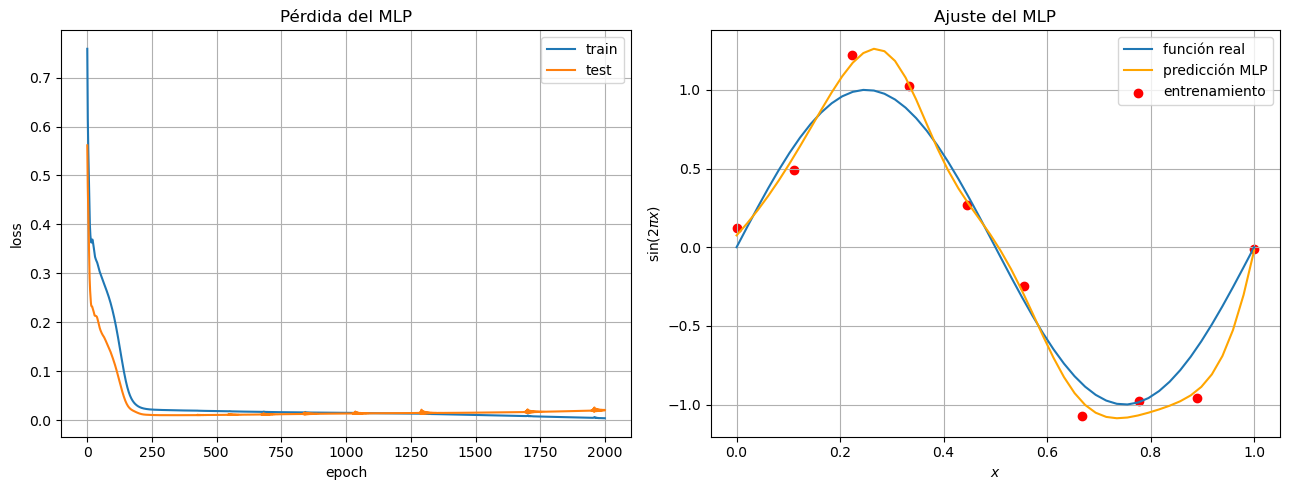

In [25]:
# Comparación visual: MLP vs. función real
mlp.eval()
with torch.no_grad():
    y_pred_mlp = mlp(x_test_tensor).cpu().numpy().squeeze()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(np.arange(EPOCHS_MLP), train_loss_mlp, label='train')
ax1.plot(np.arange(EPOCHS_MLP), test_loss_mlp, label='test')
ax1.set_title('Pérdida del MLP')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend(); ax1.grid()

ax2.plot(x_test, y_test, label='función real')
ax2.plot(x_test, y_pred_mlp, color='orange', label='predicción MLP')
ax2.scatter(x_train, y_train, color='red', label='entrenamiento')
ax2.set_title('Ajuste del MLP')
ax2.set_xlabel(r'$x$'); ax2.set_ylabel(r'$\sin(2 \pi x)$'); ax2.legend(); ax2.grid()

plt.tight_layout()
plt.show()

## Ejemplo completo: clasificación de dígitos MNIST con PyTorch

Anteriormente construimos un clasificador de dígitos **MNIST** con TensorFlow/Keras. Aquí replicamos ese mismo ejemplo, pero **implementado y entrenado con PyTorch**, para contrastar ambos enfoques.

**MNIST** es un conjunto de 70 000 imágenes en escala de grises de $28\times28$ píxeles de dígitos escritos a mano (0–9): 60 000 para entrenamiento y 10 000 para prueba. Es el "*hola mundo*" de la visión por computadora.

**Diferencias clave respecto a Keras que veremos aquí:**

- Cargamos los datos con **`torchvision.datasets`** y los iteramos con **`DataLoader`** en *mini-batches*.
- La red produce **logits** (valores sin normalizar); **no** aplicamos softmax en la última capa porque la función de pérdida **`nn.CrossEntropyLoss`** ya combina `softmax` + `log` + `NLLLoss` internamente (más estable numéricamente).
- Escribimos el **bucle de entrenamiento y evaluación** explícitamente, calculando pérdida y *accuracy* por época.


##### cargar el dataset MNIST

Usamos `torchvision.datasets.MNIST`, que descarga los datos automáticamente. La transformación `ToTensor()` convierte cada imagen a un tensor y escala los píxeles de $[0, 255]$ a $[0, 1]$; `Normalize` los estandariza usando la media y desviación típica conocidas de MNIST. Los `DataLoader` nos permiten iterar en *mini-batches* y barajar el conjunto de entrenamiento.

In [26]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

# Transformación: imagen -> tensor en [0,1] y estandarización (media y std de MNIST)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# Descarga (la primera vez) y carga de los conjuntos de entrenamiento y prueba
train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoaders: iteran en mini-batches; barajamos solo el entrenamiento
BATCH_SIZE_MNIST = 128
train_loader_mnist = DataLoader(train_dataset, batch_size=BATCH_SIZE_MNIST, shuffle=True)
test_loader_mnist  = DataLoader(test_dataset,  batch_size=BATCH_SIZE_MNIST, shuffle=False)

print("Imágenes de entrenamiento:", len(train_dataset))
print("Imágenes de prueba:       ", len(test_dataset))
print("Forma de una imagen:      ", train_dataset[0][0].shape)  # [canales, alto, ancho]

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 349kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.30MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 681kB/s]


Imágenes de entrenamiento: 60000
Imágenes de prueba:        10000
Forma de una imagen:       torch.Size([1, 28, 28])


##### visualizar algunos dígitos

Antes de entrenar, veamos con qué datos trabaja la red. Mostramos una cuadrícula de imágenes de entrenamiento con su etiqueta. Usamos `train_dataset.data` (los píxeles originales sin normalizar) solo para visualizar.

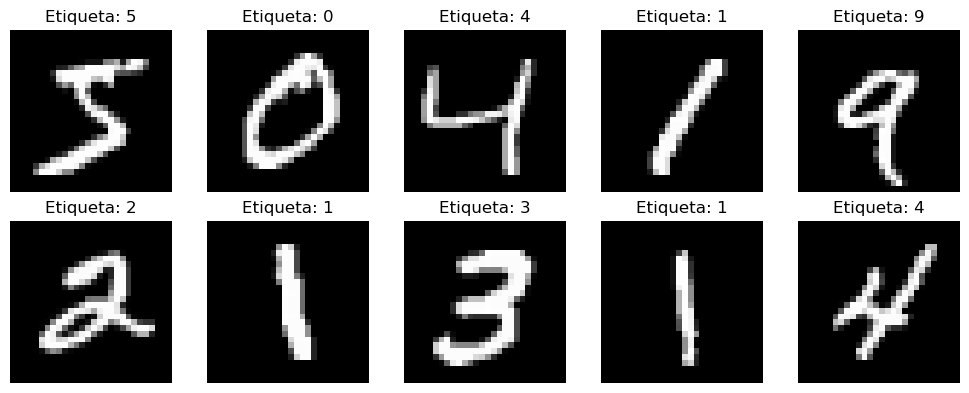

In [27]:
# Mostrar 10 dígitos de entrenamiento con su etiqueta
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_dataset.data[i], cmap='gray')
    plt.title(f'Etiqueta: {train_dataset.targets[i].item()}')
    plt.axis('off')
plt.tight_layout()
plt.show()

##### Definir la red neuronal (MLP)

Replicamos la arquitectura del ejemplo de TensorFlow: un perceptrón multicapa con **dos capas ocultas de 128 neuronas** y activación **ReLU**, y una capa de salida de **10 neuronas** (una por dígito).

- **`nn.Flatten`** aplana cada imagen de $28\times28$ en un vector de $784$ valores.
- La capa de salida devuelve **logits** (sin softmax), ya que `nn.CrossEntropyLoss` lo aplica internamente.
- Usamos `nn.Sequential`, una forma compacta de apilar capas cuando el flujo es lineal.

In [29]:
class MNISTClassifier(nn.Module):
    """MLP para clasificar dígitos MNIST: 784 -> 128 -> 128 -> 10."""
    def __init__(self, num_hidden=128, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=28*28, out_features=num_hidden),
            nn.ReLU(),
            nn.Linear(in_features=num_hidden, out_features=num_hidden),
            nn.ReLU(),                                                     
            nn.Linear(in_features=num_hidden, out_features=num_classes) # capa de salida (logits, sin softmax)
        )

            # [batch, 1, 28, 28] -> [batch, 784]

            # capa oculta 1
            # Relu
            # capa oculta 2
            
            
        

    def forward(self, x):
        return self.net(x)


#instancial un objeto del modelo
mnist_model = MNISTClassifier().to(device)

In [30]:
mnist_model

MNISTClassifier(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [31]:
# Resumen del modelo: capas, formas de salida y número de parámetros
from torchinfo import summary
summary(mnist_model, input_size=(BATCH_SIZE_MNIST, 1, 28, 28))


Layer (type:depth-idx)                   Output Shape              Param #
MNISTClassifier                          [128, 10]                 --
├─Sequential: 1-1                        [128, 10]                 --
│    └─Flatten: 2-1                      [128, 784]                --
│    └─Linear: 2-2                       [128, 128]                100,480
│    └─ReLU: 2-3                         [128, 128]                --
│    └─Linear: 2-4                       [128, 128]                16,512
│    └─ReLU: 2-5                         [128, 128]                --
│    └─Linear: 2-6                       [128, 10]                 1,290
Total params: 118,282
Trainable params: 118,282
Non-trainable params: 0
Total mult-adds (M): 15.14
Input size (MB): 0.40
Forward/backward pass size (MB): 0.27
Params size (MB): 0.47
Estimated Total Size (MB): 1.15

##### Función de pérdida, optimizador y bucle de entrenamiento

- **Pérdida**: `nn.CrossEntropyLoss`, adecuada para clasificación multiclase (combina softmax + log-verosimilitud negativa).
- **Optimizador**: `Adam`, que converge rápido.

Definimos dos funciones auxiliares para mantener el código limpio: una para **entrenar una época** y otra para **evaluar**. En cada época recorremos todos los *mini-batches*, aplicando los 5 pasos del entrenamiento, y medimos la **pérdida** y la **precisión** (*accuracy*) tanto en entrenamiento como en prueba.

In [32]:
criterion_mnist = nn.CrossEntropyLoss()
optimizer_mnist = Adam(mnist_model.parameters(), lr=0.001)

def entrenar_una_epoca(model, loader, criterion, optimizer):
    model.train()                              # modo entrenamiento
    loss_total, aciertos, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()                  # 1. limpiar gradientes
        logits = model(images)                 # 2. forward pass
        loss = criterion(logits, labels)       # 3. calcular la pérdida
        loss.backward()                        # 4. backward pass
        optimizer.step()                       # 5. actualizar pesos

        loss_total += loss.item() * images.size(0)
        aciertos += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return loss_total / total, aciertos / total


def evaluar(model, loader, criterion):
    model.eval()                               # modo evaluación
    loss_total, aciertos, total = 0.0, 0, 0
    with torch.no_grad():                      # sin gradientes: más rápido
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            loss_total += loss.item() * images.size(0)
            aciertos += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return loss_total / total, aciertos / total

In [33]:
# Entrenamiento durante varias épocas, guardando métricas para graficar
EPOCHS_MNIST = 10
hist = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(1, EPOCHS_MNIST + 1):
    # entrenar una epoca
    tr_loss, tr_acc = entrenar_una_epoca(mnist_model, train_loader_mnist, criterion_mnist, optimizer_mnist)

    # evaluar
    te_loss, te_acc = evaluar(mnist_model, test_loader_mnist, criterion_mnist)

    #historico de loss
    hist['train_loss'].append(tr_loss)
    hist['test_loss'].append(te_loss)
    hist['train_acc'].append(tr_acc)
    hist['test_acc'].append(te_acc)

    print(f"Época {epoch:2d}/{EPOCHS_MNIST} | "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"test_loss={te_loss:.4f} acc={te_acc:.4f}")

Época  1/10 | train_loss=0.2993 acc=0.9112 | test_loss=0.1389 acc=0.9582
Época  2/10 | train_loss=0.1194 acc=0.9640 | test_loss=0.0967 acc=0.9695
Época  3/10 | train_loss=0.0819 acc=0.9746 | test_loss=0.0833 acc=0.9736
Época  4/10 | train_loss=0.0622 acc=0.9805 | test_loss=0.0794 acc=0.9758
Época  5/10 | train_loss=0.0495 acc=0.9841 | test_loss=0.0743 acc=0.9769
Época  6/10 | train_loss=0.0402 acc=0.9868 | test_loss=0.0712 acc=0.9781
Época  7/10 | train_loss=0.0330 acc=0.9891 | test_loss=0.0744 acc=0.9790
Época  8/10 | train_loss=0.0265 acc=0.9909 | test_loss=0.0928 acc=0.9747
Época  9/10 | train_loss=0.0231 acc=0.9922 | test_loss=0.0795 acc=0.9764
Época 10/10 | train_loss=0.0185 acc=0.9939 | test_loss=0.0931 acc=0.9771


##### Curvas de entrenamiento

Graficamos la **pérdida** y la **precisión** de entrenamiento frente a las de prueba, época a época. Si la curva de entrenamiento sigue mejorando mientras la de prueba se estanca, sería señal de **sobreajuste**.

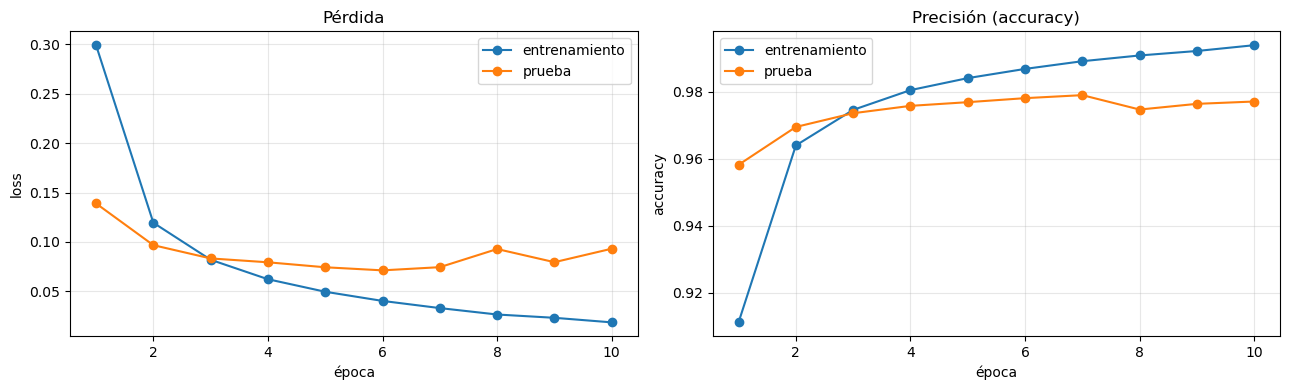

Precisión final en prueba: 0.9771


In [34]:
epochs_range = np.arange(1, EPOCHS_MNIST + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_range, hist['train_loss'], marker='o', label='entrenamiento')
ax1.plot(epochs_range, hist['test_loss'], marker='o', label='prueba')
ax1.set_title('Pérdida'); ax1.set_xlabel('época'); ax1.set_ylabel('loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, hist['train_acc'], marker='o', label='entrenamiento')
ax2.plot(epochs_range, hist['test_acc'], marker='o', label='prueba')
ax2.set_title('Precisión (accuracy)'); ax2.set_xlabel('época'); ax2.set_ylabel('accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Precisión final en prueba: {hist['test_acc'][-1]:.4f}")

##### Evaluación

Recolectamos las predicciones sobre todo el conjunto de prueba para construir la **matriz de confusión** (qué dígitos se confunden entre sí) y el **reporte de clasificación** (precision, recall y F1 por dígito).

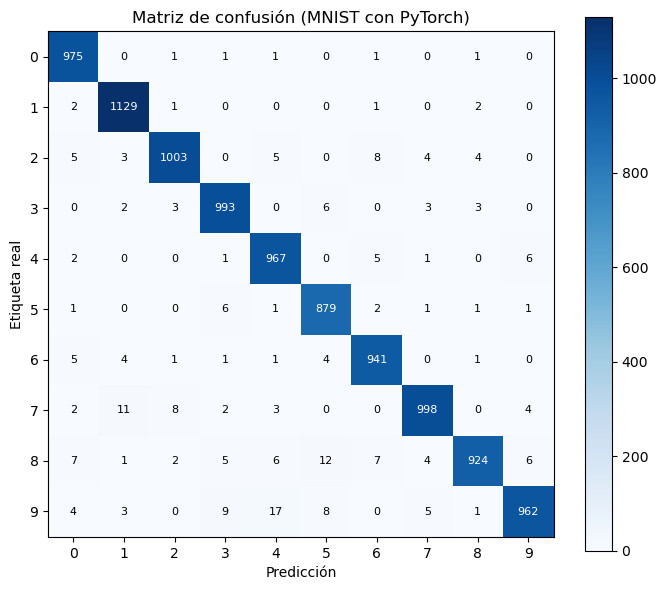

              precision    recall  f1-score   support

           0      0.972     0.995     0.983       980
           1      0.979     0.995     0.987      1135
           2      0.984     0.972     0.978      1032
           3      0.975     0.983     0.979      1010
           4      0.966     0.985     0.975       982
           5      0.967     0.985     0.976       892
           6      0.975     0.982     0.979       958
           7      0.982     0.971     0.977      1028
           8      0.986     0.949     0.967       974
           9      0.983     0.953     0.968      1009

    accuracy                          0.977     10000
   macro avg      0.977     0.977     0.977     10000
weighted avg      0.977     0.977     0.977     10000



In [35]:
from sklearn.metrics import confusion_matrix, classification_report

# Recolectar predicciones y etiquetas reales de todo el conjunto de prueba
mnist_model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader_mnist:
        images = images.to(device)
        preds = mnist_model(images).argmax(1).cpu()
        y_pred.extend(preds.numpy())
        y_true.extend(labels.numpy())

y_true, y_pred = np.array(y_true), np.array(y_pred)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(10)); plt.yticks(range(10))
plt.xlabel('Predicción'); plt.ylabel('Etiqueta real')
plt.title('Matriz de confusión (MNIST con PyTorch)')
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=8)
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, digits=3))

##### Visualizar predicciones

Mostramos 15 imágenes del conjunto de prueba con la predicción del modelo. El título va en **verde** si la predicción es correcta y en **rojo** si es un error (indicando la etiqueta real).

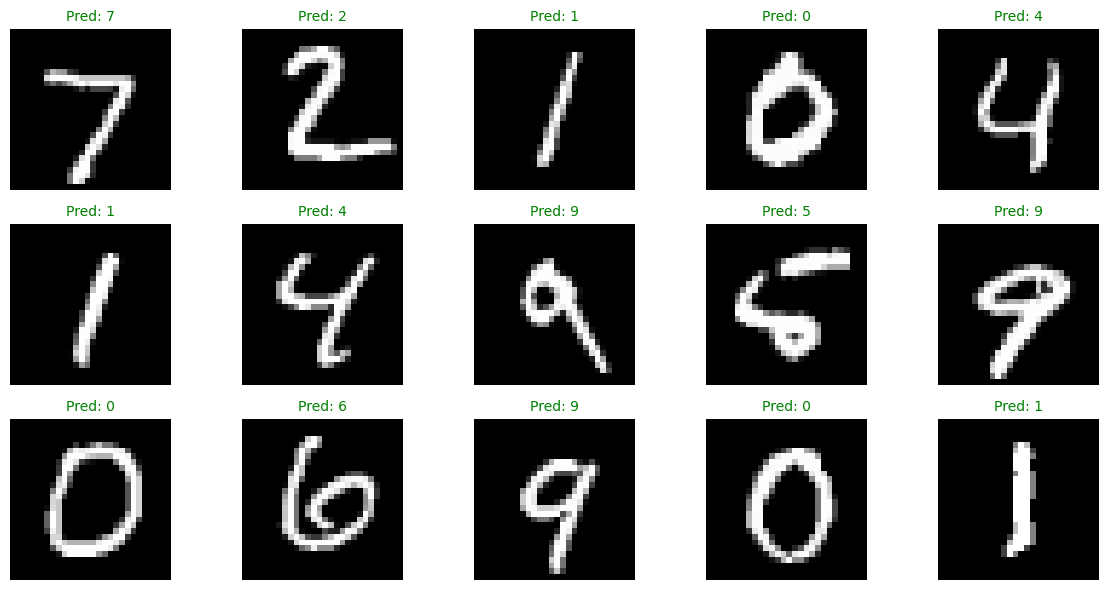

In [36]:
# Tomamos un lote del conjunto de prueba y predecimos
images, labels = next(iter(test_loader_mnist))
mnist_model.eval()
with torch.no_grad():
    preds = mnist_model(images.to(device)).argmax(1).cpu()

plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')   # squeeze quita la dimensión de canal
    correcto = preds[i].item() == labels[i].item()
    color = 'green' if correcto else 'red'
    titulo = f'Pred: {preds[i].item()}' if correcto else f'Pred: {preds[i].item()} (real {labels[i].item()})'
    plt.title(titulo, color=color, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()


#### Tabla Comparativa entre PyTorch vs. Keras/TensorFlow

|  | PyTorch | Keras (TF) |
|---|---|---|
| Bucle de entrenamiento | Explícito (más control) | `model.fit()` (más automático) |
| Estilo del grafo | Dinámico (*define-by-run*) | Estático/compilado (por defecto) |
| Definición del modelo | Clase que hereda de `nn.Module` | `Sequential` / API funcional |
| Gradientes | `loss.backward()` (autograd) | Automático dentro de `fit` |
